<a href="https://colab.research.google.com/github/angelrecalde2024/Power-Distribution-Design-and-Management/blob/main/INGP1120_DistributionLoadFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD FLOW OF ELECTRICAL DISTRIBUTION SYSTEM WITH OPEN DSS

The model of the distribution system has been built in OpenDSS. We do not want to rebuild the feeder in Python. If topology is changed, perform upgrades in OpenDSS first and then continue as usual in Python (Google Colab).

Python in Google Colab allows to do perform several studies on the distribution system, e.g., PV penetration, EV charging scenario, and others.

STEP 1

This cell mounts your Drive (there must be a folder with the OpenDSS files), installs OpenDSSDirect.py (stabe interface for Googla Colab), defines the path to your feeder folder.






In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install OpenDSS Python interface
!pip install opendssdirect.py

# Import library
import opendssdirect as dss
import os

# Path to the folder containing Master.dss and all other DSS files
feeder_path = "/content/drive/MyDrive/CNEL_Anconcito2024"

# Check folder contents
print("Files in feeder folder:")
print(os.listdir(feeder_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in feeder folder:
['XfmrCodes.dss', 'WireData.dss', 'Devices_MV.dss', 'LineGeometry.dss', 'BusCoords_MV.csv', 'Capacitors_MV.dss', 'Lines_MV.dss', 'Transformers_MVLV.dss', 'Voltage_Bases_DSS.DSS', 'Loads_MV.dss', 'Faults_MV.dss', 'Reclosers_MV.dss', 'Monitors_MV.dss', 'Master.dss', 'Fuses_MV.dss', 'MTR_feeder_head.csv', 'SystemMeter_1.csv']


STEP 2

This cell compiles Master.dss, runs the power flow, retrieves bus voltages in per unit, and prints the first buses as verification.

In [12]:
# Compile the OpenDSS model
master_file = os.path.join(feeder_path, "Master.dss")

dss.Text.Command(f"compile [{master_file}]")

# Solve power flow
dss.Solution.Solve()

print("Solution status:", dss.Solution.Converged())

# Retrieve bus names
bus_names = dss.Circuit.AllBusNames()

# Retrieve voltage magnitudes (per unit)
voltages_pu = dss.Circuit.AllBusMagPu()

# Display first 10 buses
print("\nFirst 10 bus voltages (pu):")
for i in range(min(10, len(bus_names))):
    print(f"{bus_names[i]} : {voltages_pu[i]:.4f} pu")

Solution status: True

First 10 bus voltages (pu):
nodofuente_16sv070t14 : 0.9882 pu
mta_s_23283 : 0.9900 pu
mta_s_23284 : 0.9833 pu
mta_s_7160 : 0.8496 pu
mta_s_7161 : 0.8496 pu
mta_s_115667 : 0.9558 pu
mta_s_115668 : 0.9587 pu
mta_s_42581 : 0.8893 pu
mta_s_42582 : 0.9557 pu
mta_s_7455 : 0.9586 pu


DATA AVAILABLE FROM OPENDSS

The engine returns many values.

*  Bus voltages:  Circuit.AllBusMagPu()
*  Bus names:     Circuit.AllBusNames()
*  Line currents: Lines.Currents()
*  Power flows:   CktElement.Powers()
*  Losses:        Circuit.Losses()

All these values can be plotted. AllBusMagPu() returns voltages per node, not exactly one value per bus. We separate each phase to plot the voltage per phase.


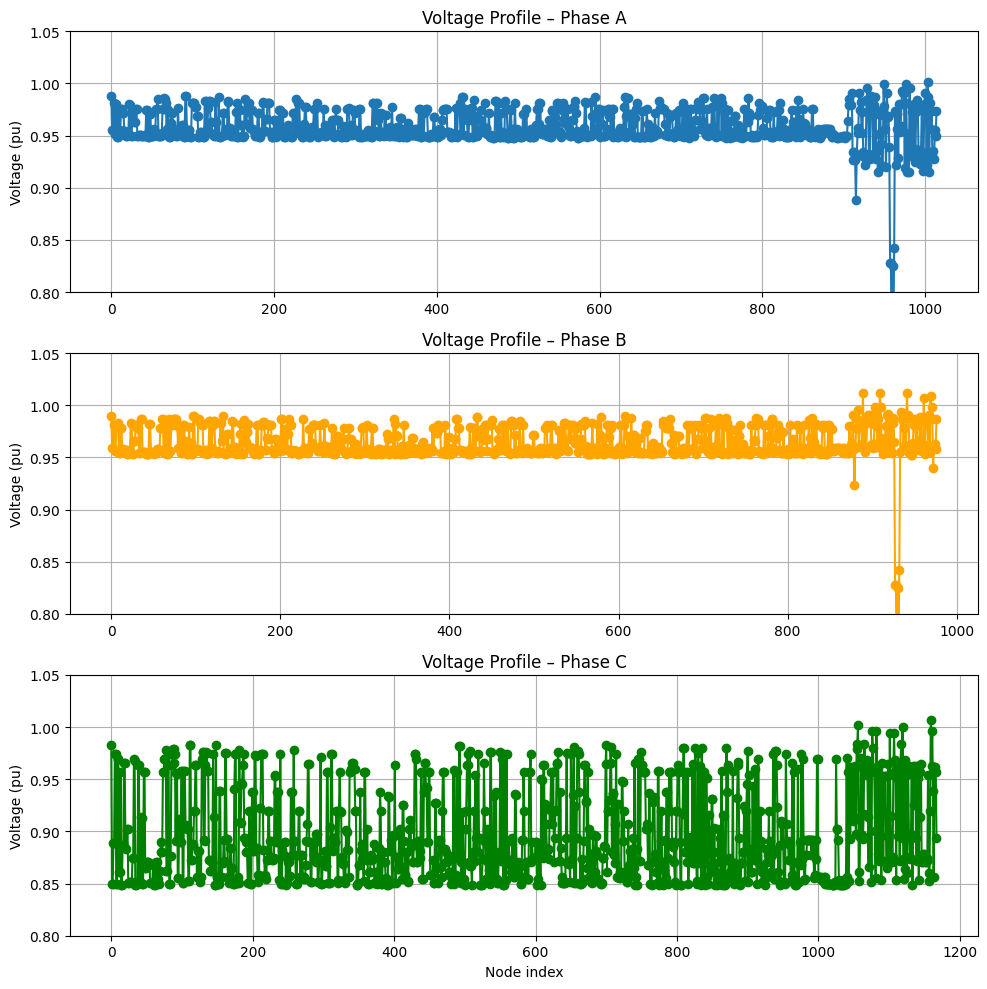

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Retrieve all buses
bus_names = dss.Circuit.AllBusNames()

# Containers for each phase
phaseA = []
phaseB = []
phaseC = []

for bus in bus_names:

    dss.Circuit.SetActiveBus(bus)

    # Node numbers at the bus (phase identifiers)
    nodes = dss.Bus.Nodes()

    # Voltage magnitudes per unit at the bus
    vmag = dss.Bus.puVmagAngle()[::2]  # take only magnitudes

    for node, v in zip(nodes, vmag):
        if node == 1:
            phaseA.append(v)
        elif node == 2:
            phaseB.append(v)
        elif node == 3:
            phaseC.append(v)

# Convert to numpy arrays
phaseA = np.array(phaseA)
phaseB = np.array(phaseB)
phaseC = np.array(phaseC)

# Create index for plotting
idxA = np.arange(len(phaseA))
idxB = np.arange(len(phaseB))
idxC = np.arange(len(phaseC))

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10,10), sharex=False)

axs[0].plot(idxA, phaseA, 'o-', label='Phase A')
axs[0].set_title("Voltage Profile – Phase A")
axs[0].set_ylabel("Voltage (pu)")
axs[0].grid(True)
axs[0].set_ylim(0.8,1.05)

axs[1].plot(idxB, phaseB, 'o-', label='Phase B', color='orange')
axs[1].set_title("Voltage Profile – Phase B")
axs[1].set_ylabel("Voltage (pu)")
axs[1].grid(True)
axs[1].set_ylim(0.8,1.05)

axs[2].plot(idxC, phaseC, 'o-', label='Phase C', color='green')
axs[2].set_title("Voltage Profile – Phase C")
axs[2].set_xlabel("Node index")
axs[2].set_ylabel("Voltage (pu)")
axs[2].grid(True)
axs[2].set_ylim(0.8,1.05)

plt.tight_layout()
plt.show()

VOLTAGE HISTOGRAM BY PHASE

A voltage histogram by phase is an excellent diagnostic plot because it shows the distribution of voltages across the feeder, not just the profile. This becomes extremely useful later when we perform: PV penetration, EV chargning, capacitor placement, voltage regulation.

We will reuse the phase voltage arrays (phase A, phase B, phase C) that were already computed in the previous cell.

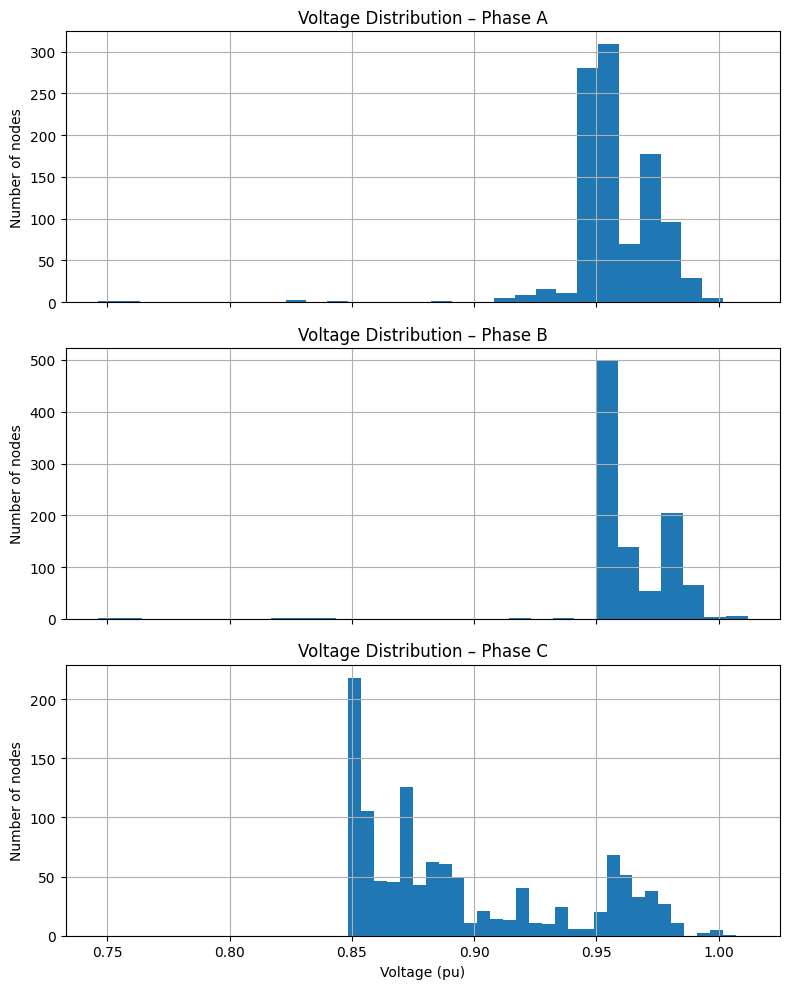

In [14]:
import matplotlib.pyplot as plt

# Create histogram plots
fig, axs = plt.subplots(3, 1, figsize=(8,10), sharex=True)

# Phase A
axs[0].hist(phaseA, bins=30)
axs[0].set_title("Voltage Distribution – Phase A")
axs[0].set_ylabel("Number of nodes")
axs[0].grid(True)

# Phase B
axs[1].hist(phaseB, bins=30)
axs[1].set_title("Voltage Distribution – Phase B")
axs[1].set_ylabel("Number of nodes")
axs[1].grid(True)

# Phase C
axs[2].hist(phaseC, bins=30)
axs[2].set_title("Voltage Distribution – Phase C")
axs[2].set_xlabel("Voltage (pu)")
axs[2].set_ylabel("Number of nodes")
axs[2].grid(True)

plt.tight_layout()
plt.show()

VOLTAGE vs DISTANCE PROFILE

**TRADITIONAL OPTION**

To perform the voltage vs. distance for a radial distribution network, we need to transform our branch-based power flow results into **continuous trajectories** from the substation (source) to each leaf node (end of branch).

1.  Build a Directed Graph (Tree)

First, represent the network topology as a mathematical tree. Each node is a bus, and each branch is an edge with a weight equal to its physical length. The steps are: 1) data structure: create an adjacency list where each parent node points to its children. 2) root identification: define the substation (slack bus) as the rrot (node 0).

2. Identify all unique paths (branch-Tree algorithm)

A radial network is effectively a collection of overlapping paths. To find the 'ramifications', use a Depth-First Search (DFS) or a recursive path-finding algorihtm. The steps are: 1) start at the root, 2) traverse down a branch until we hit a Loaf Node (a bus with no downstream connections), 3) store this sequence of nodes as one 'feeder path', 4) backtrack to the last junction and follow the next available child until all leaves are reached.

3. Calculate cumulative distance and per-phase voltage

For each unique path identified in step 2, organize your data into a table or array. The steps are: 1) distance ($x$-axis): for each node $i$ in a path, the distance is the sum of all branch lengths from the root to node $i$, 2) voltage ($y$-axis): extract the voltage magnitude (per phase, $V_a$,$V_b$,$V_c$) for those specific nodes from the power flow output.

4. Plotting Strategy

To visualize the 'ramifications' clearly, do not plot everything as a single line. Instead: 1) overlay lines: plot each unique path as a separate line on the same graph, 2) phase separation: use three separate subplots (one for phase A, B, C) or use different line styles (solid, dashed, dotted) to distinguish phase on one plot, 3) common origin: all lines will start at the same point (distance 0, voltage = 1.0 p.u.) and 'fan-out' as they reach different parts of the network'.



**OPENDSS APROACH TO PLOT**

There is a much simpler algorithm that works directly with OpenDSS data and avoids explicitly running DFS. This alternative method is often used for very large feeders (1000+ line segments) and is computationally cleaner. This methods uses CalcDistances().

However, the command CalcDistances() is not available in the DSS command interpreter when using the Python interface. It exists internally in some OpenDSS tools, but the correct way to trigeer the distance calculation from scripts is through **energy meters**.

OpenDSS computes bus distances when an energy meter defines the feeder zone. Without a meter, the engine does no know which element is the feeder root, so Bus.Distance() remains undefined.

The correct workflow is:

*  Define an **EnergyMeter** at the feeder head (substation line of transformer)
*  Solve the circuit
*  OpenDSS automatically computes distance along the meter zone.
*  Retrieve distances with dss.Bus.Distance().

In our current model in MAster.dss, we have the following declaration with an Energy Meter at the head of the feeder:

```
New Energymeter.Feeder_HEAD Element=Line.N_1244_MTS Terminal=2
```

With this declaration of a meter, OpenDSS automatically discovers the feeder topology, and the distances propagate through all downstream buses. them the command Bus.Distance() returns the cumulative feeder length.





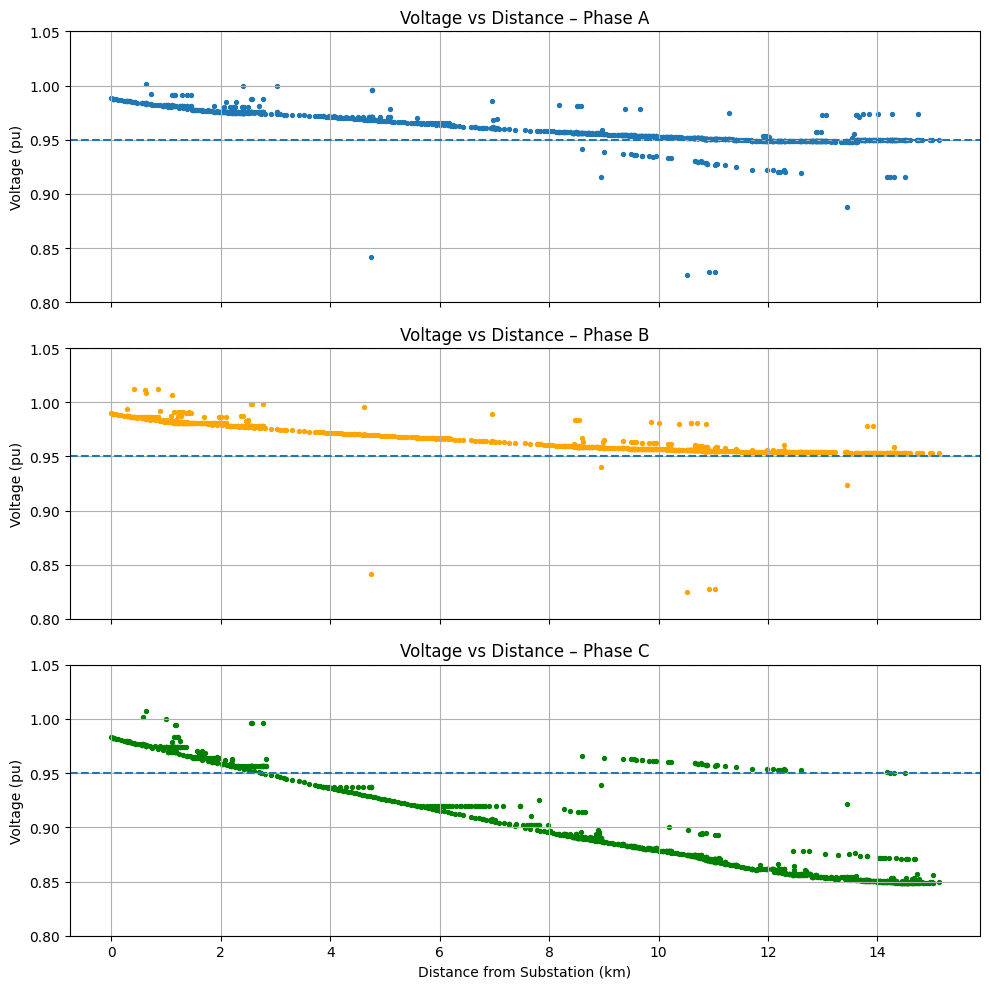

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the circuit solution exists
dss.Solution.Solve()

# Force meter processing so feeder distances are propagated
dss.Meters.Sample()
dss.Meters.SaveAll()

# Containers for phases
distA, voltA = [], []
distB, voltB = [], []
distC, voltC = [], []

# Get all buses
bus_names = dss.Circuit.AllBusNames()

for bus in bus_names:

    dss.Circuit.SetActiveBus(bus)

    # Distance from feeder head (km)
    dist = dss.Bus.Distance()

    # Phase identifiers
    nodes = dss.Bus.Nodes()

    # Voltage magnitudes (pu)
    vmag = dss.Bus.puVmagAngle()[::2]

    for node, v in zip(nodes, vmag):

        if node == 1:   # Phase A
            distA.append(dist)
            voltA.append(v)

        elif node == 2: # Phase B
            distB.append(dist)
            voltB.append(v)

        elif node == 3: # Phase C
            distC.append(dist)
            voltC.append(v)

# Convert to numpy arrays
distA, voltA = np.array(distA), np.array(voltA)
distB, voltB = np.array(distB), np.array(voltB)
distC, voltC = np.array(distC), np.array(voltC)

# Sort values by distance for cleaner visualization
orderA = np.argsort(distA)
orderB = np.argsort(distB)
orderC = np.argsort(distC)

distA, voltA = distA[orderA], voltA[orderA]
distB, voltB = distB[orderB], voltB[orderB]
distC, voltC = distC[orderC], voltC[orderC]

# Plot
fig, axs = plt.subplots(3, 1, figsize=(10,10), sharex=True)

axs[0].scatter(distA, voltA, s=8)
axs[0].set_title("Voltage vs Distance – Phase A")
axs[0].set_ylabel("Voltage (pu)")
axs[0].grid(True)
axs[0].set_ylim(0.8,1.05)

axs[1].scatter(distB, voltB, s=8, color='orange')
axs[1].set_title("Voltage vs Distance – Phase B")
axs[1].set_ylabel("Voltage (pu)")
axs[1].grid(True)
axs[1].set_ylim(0.8,1.05)

axs[2].scatter(distC, voltC, s=8, color='green')
axs[2].set_title("Voltage vs Distance – Phase C")
axs[2].set_xlabel("Distance from Substation (km)")
axs[2].set_ylabel("Voltage (pu)")
axs[2].grid(True)
axs[2].set_ylim(0.8,1.05)

# Voltage limits
for ax in axs:
    ax.axhline(0.95, linestyle='--')
    ax.axhline(1.05, linestyle='--')

plt.tight_layout()
plt.show()

COORDINATE-CONSISTENCY CHECK

For feeder visualization, data integrity between Lines_MV.dss and BusCoods_MV.dss **is critical**, and catching mismatches early will save a lot of debugging time.

In [17]:
import os
import re
import pandas as pd

# Paths (adjust if needed)
lines_file = os.path.join(feeder_path, "Lines_MV.dss")
coords_file = os.path.join(feeder_path, "BusCoords_MV.csv")

# -----------------------------
# 1. Read coordinate file
# -----------------------------
coords_df = pd.read_csv(coords_file, header=None, names=["bus","x","y"])

# Normalize bus names (uppercase)
coords_df["bus"] = coords_df["bus"].str.upper()

# Build coordinate dictionary
coord_buses = set(coords_df["bus"])

print(f"Total buses with coordinates: {len(coord_buses)}")

# -----------------------------
# 2. Parse Lines_MV.dss
# -----------------------------
line_buses = set()

with open(lines_file, "r") as f:

    for line in f:

        line = line.strip()

        if line.lower().startswith("new line"):

            # extract bus1 and bus2
            m1 = re.search(r"bus1=([^\s]+)", line, re.IGNORECASE)
            m2 = re.search(r"bus2=([^\s]+)", line, re.IGNORECASE)

            if m1 and m2:

                b1 = m1.group(1)
                b2 = m2.group(1)

                # remove phase suffix
                b1 = b1.split('.')[0].upper()
                b2 = b2.split('.')[0].upper()

                line_buses.add(b1)
                line_buses.add(b2)

print(f"Total buses referenced in Lines_MV.dss: {len(line_buses)}")

# -----------------------------
# 3. Check missing coordinates
# -----------------------------
missing = sorted(line_buses - coord_buses)

print("\nBuses missing coordinates:", len(missing))

for b in missing[:20]:   # show first 20
    print(b)

if len(missing) > 20:
    print("...")

# -----------------------------
# 4. Check unused coordinates
# -----------------------------
unused = sorted(coord_buses - line_buses)

print("\nCoordinate entries not used in Lines_MV.dss:", len(unused))

Total buses with coordinates: 1648
Total buses referenced in Lines_MV.dss: 1430

Buses missing coordinates: 0

Coordinate entries not used in Lines_MV.dss: 218


FEEDER GEOMETRY DATASET

Now that the coordinate dataset is validated, the next step is to build the feeder geometry dataset that will be used for voltage heatmap.

This cell will:

1.  load the coordinate table
2.  parse Lines_MV.dss
3.  extract bus 1, bus 2, and phases
4.  match buses with coordinates
5.  construct a geometry table with line segments.

This table will be skeleton of the feeder drawing.



In [18]:
import pandas as pd
import os
import re

# Paths
lines_file = os.path.join(feeder_path, "Lines_MV.dss")
coords_file = os.path.join(feeder_path, "BusCoords_MV.csv")

# -----------------------------
# Load bus coordinates
# -----------------------------
coords_df = pd.read_csv(coords_file, header=None, names=["bus","x","y"])
coords_df["bus"] = coords_df["bus"].str.upper()

# Convert to dictionary for fast lookup
coord_dict = dict(zip(coords_df["bus"], zip(coords_df["x"], coords_df["y"])))

# -----------------------------
# Parse Lines_MV.dss
# -----------------------------
segments = []

with open(lines_file, "r") as f:

    for line in f:

        line = line.strip()

        if line.lower().startswith("new line"):

            # Extract line name
            name_match = re.search(r"new\s+line\.([^\s]+)", line, re.IGNORECASE)

            # Extract buses
            bus1_match = re.search(r"bus1=([^\s]+)", line, re.IGNORECASE)
            bus2_match = re.search(r"bus2=([^\s]+)", line, re.IGNORECASE)

            # Extract phases
            phase_match = re.search(r"phases=(\d+)", line, re.IGNORECASE)

            if name_match and bus1_match and bus2_match:

                line_name = name_match.group(1)

                bus1 = bus1_match.group(1).split('.')[0].upper()
                bus2 = bus2_match.group(1).split('.')[0].upper()

                phases = int(phase_match.group(1)) if phase_match else 3

                # Get coordinates
                if bus1 in coord_dict and bus2 in coord_dict:

                    x1,y1 = coord_dict[bus1]
                    x2,y2 = coord_dict[bus2]

                    segments.append({
                        "line": line_name,
                        "bus1": bus1,
                        "bus2": bus2,
                        "x1": x1,
                        "y1": y1,
                        "x2": x2,
                        "y2": y2,
                        "phases": phases
                    })

# Convert to DataFrame
segments_df = pd.DataFrame(segments)

print("Total line segments:", len(segments_df))
segments_df.head()

Total line segments: 1430


,line,bus1,bus2,x1,y1,x2,y2,phases
0,N_23283_MTA,MTA_S_23283,MTA_S_23284,512105.22,9742634.57,512105.22,9742633.57,1
1,N_7160_MTA,MTA_S_7160,MTA_S_7161,509775.00,9746348.00,509803.00,9746316.00,3
2,N_115667_MTA,MTA_S_115667,MTA_S_115668,511696.29,9751881.81,511697.46,9751882.31,1
3,N_42581_MTA,MTA_S_42581,MTA_S_42582,510996.25,9744963.66,510996.38,9744963.33,2
4,N_7454_MTA,MTA_S_7455,MTA_S_7454,512118.16,9742617.88,512132.54,9742599.67,1


In [21]:
import pandas as pd
import numpy as np

bus_names = dss.Circuit.AllBusNames()

bus_voltage_data = []

for bus in bus_names:

    dss.Circuit.SetActiveBus(bus)

    nodes = dss.Bus.Nodes()

    # Voltage magnitudes in pu
    vmag = dss.Bus.puVmagAngle()[::2]

    if len(vmag) > 0:
        vmin = np.min(vmag)
    else:
        vmin = np.nan

    bus_voltage_data.append({
        "bus": bus.upper(),
        "vmin": vmin
    })

bus_voltage_df = pd.DataFrame(bus_voltage_data)

print("Total buses with voltage results:", len(bus_voltage_df))

print("Minimum feeder voltage:", bus_voltage_df["vmin"].min())
print("Maximum feeder voltage:", bus_voltage_df["vmin"].max())
print("Average feeder voltage:", bus_voltage_df["vmin"].mean())

bus_voltage_df.head()



Total buses with voltage results: 1674
Minimum feeder voltage: 0.7461645545941359
Maximum feeder voltage: 1.0118486294419955
Average feeder voltage: 0.9164408110253842


,bus,vmin
0,NODOFUENTE_16SV070T14,0.983319
1,MTA_S_23283,0.849626
2,MTA_S_23284,0.849626
3,MTA_S_7160,0.889305
4,MTA_S_7161,0.888955


VOLTAGE HEATMAP

With feeder geometry (lines and coordinates), and minimum voltage per bus, we can combine them to produce the voltage heatmap of the feeder.

This plot can immediately reveal: long weak laterals, voltage pockets, phase imbalance effects, regulator influence, capacitor improvements.

This plot can be reused to illustrate: PV penetration (voltage rise), EV charging (voltage drop), capacitor placement (profile improves), network reinforcement (weak sections disappear).

This voltage heatmap includes: substation marker, thicker trunk lines, voltage violation highlighting for buses below a user-defined threshold.

This cell assumes the previous objects already exist: segments_df (geometry + phases), bus_voltage_df (minimum voltage per bus), coords_df (bus coordinates).

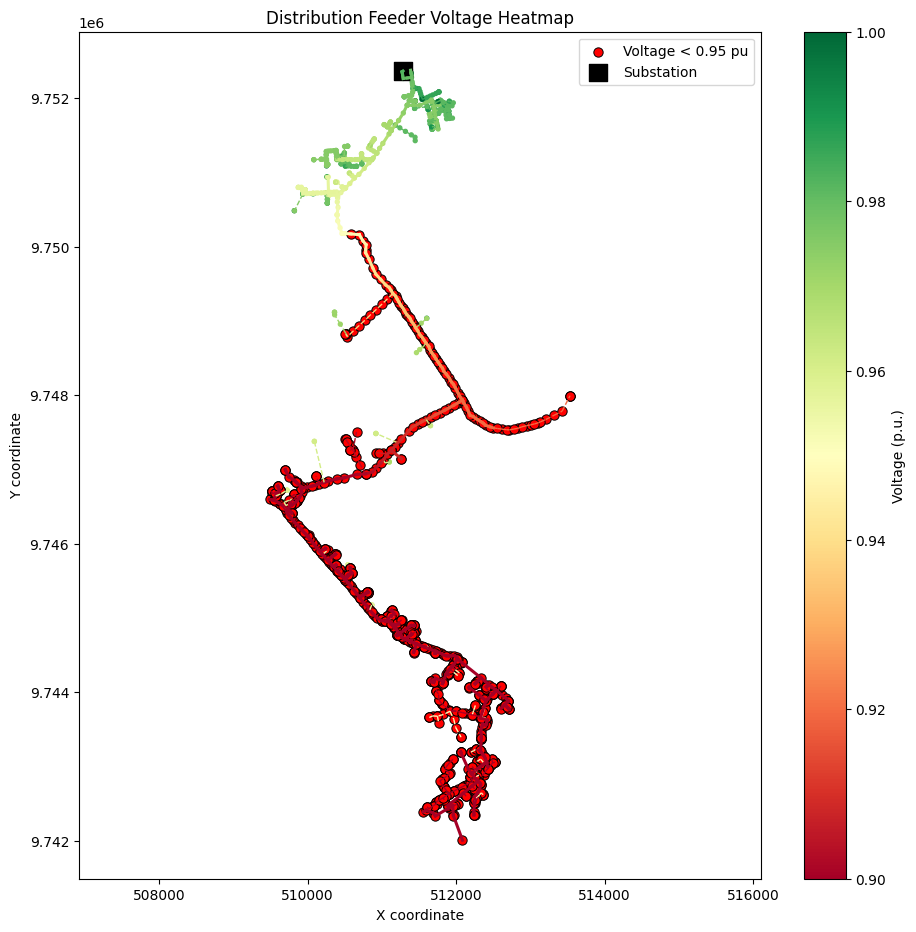

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib as mpl

# -----------------------------
# USER PARAMETERS
# -----------------------------

V_LIMIT = 0.95   # voltage violation threshold
SUBSTATION_BUS = "NODOFUENTE_16SV070T14"  # uppercase name of substation bus

V_MIN = 0.90
V_MAX = 1.00


# -----------------------------
# Merge voltage into geometry
# -----------------------------

voltage_dict = dict(zip(bus_voltage_df["bus"], bus_voltage_df["vmin"]))

segments_df["vline"] = segments_df.apply(
    lambda r: np.nanmin([
        voltage_dict.get(r["bus1"], np.nan),
        voltage_dict.get(r["bus2"], np.nan)
    ]),
    axis=1
)

# -----------------------------
# Colormap
# -----------------------------

norm = mcolors.Normalize(vmin=V_MIN, vmax=V_MAX)
cmap = mpl.colormaps["RdYlGn"]


# -----------------------------
# Create figure
# -----------------------------

fig, ax = plt.subplots(figsize=(11,11))


# -----------------------------
# Plot feeder lines
# -----------------------------

for _, row in segments_df.iterrows():

    x = [row["x1"], row["x2"]]
    y = [row["y1"], row["y2"]]

    color = cmap(norm(row["vline"]))

    if row["phases"] == 3:
        lw = 2.2
        style = "-"
    else:
        lw = 1.0
        style = "--"

    ax.plot(x, y, color=color, linestyle=style, linewidth=lw)


# -----------------------------
# Plot buses
# -----------------------------

coords_df["bus"] = coords_df["bus"].str.upper()
coords_voltage = coords_df.merge(bus_voltage_df, on="bus", how="left")

sc = ax.scatter(
    coords_voltage["x"],
    coords_voltage["y"],
    c=coords_voltage["vmin"],
    cmap=cmap,
    norm=norm,
    s=8
)


# -----------------------------
# Highlight voltage violations
# -----------------------------

viol = coords_voltage[coords_voltage["vmin"] < V_LIMIT]

ax.scatter(
    viol["x"],
    viol["y"],
    s=45,
    facecolor="red",
    edgecolor="black",
    linewidth=0.7,
    label=f"Voltage < {V_LIMIT} pu"
)


# -----------------------------
# Plot substation marker
# -----------------------------

sub = coords_voltage[coords_voltage["bus"] == SUBSTATION_BUS]

if not sub.empty:

    ax.scatter(
        sub["x"],
        sub["y"],
        marker="s",
        s=160,
        facecolor="black",
        edgecolor="black",
        hatch="////",
        label="Substation"
    )


# -----------------------------
# Colorbar
# -----------------------------

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Voltage (p.u.)")


# -----------------------------
# Formatting
# -----------------------------

ax.set_title("Distribution Feeder Voltage Heatmap")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

ax.axis("equal")

ax.legend()

plt.show()

LOSS ANALYSIS

This cell computes: total feeder losses (kW, kVAr), source power (kW), loss percentage, losses per line element, top-10 highest-loss lines.

This summary tells: where the feeder dissipates most power, which sections are electrically stressed.

We should observe that high losses typically occur because the loss power is proportional to the squared current multiplied by the conductor's resistance. So large losses indicate: high current, long conductor, small conductor size, downstream load concentration.

Some of the questions we can answer are:

*  Why do these lines concentrate losses?
*  Are they trunk sections or laterals?
*  Would capacitor placement reduce these losses?
*  Would reconductoring be justified?

This is very practical for distribution planning.

In [25]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Total feeder losses
# -----------------------------

losses = dss.Circuit.Losses()

P_loss_kW = losses[0] / 1000
Q_loss_kVAr = losses[1] / 1000

# Source power
total_power = dss.Circuit.TotalPower()

P_source_kW = abs(total_power[0])

loss_percent = 100 * P_loss_kW / P_source_kW


print("----- FEEDER LOSS SUMMARY -----")
print(f"Total active loss:   {P_loss_kW:.2f} kW")
print(f"Total reactive loss: {Q_loss_kVAr:.2f} kVAr")
print(f"Source power:        {P_source_kW:.2f} kW")
print(f"Loss percentage:     {loss_percent:.2f} %")


# -----------------------------
# 2. Losses per line
# -----------------------------

line_names = dss.Lines.AllNames()

line_data = []

for line in line_names:

    dss.Lines.Name(line)

    losses = dss.CktElement.Losses()

    P = losses[0] / 1000
    Q = losses[1] / 1000

    length = dss.Lines.Length()

    phases = dss.Lines.Phases()

    line_data.append({
        "line": line,
        "phases": phases,
        "length_km": length,
        "P_loss_kW": P,
        "Q_loss_kVAr": Q
    })

line_loss_df = pd.DataFrame(line_data)


# -----------------------------
# 3. Rank highest loss lines
# -----------------------------

top_losses = line_loss_df.sort_values(
    by="P_loss_kW", ascending=False
).head(10)

print("\n----- TOP 10 LINE LOSSES -----")
display(top_losses)

----- FEEDER LOSS SUMMARY -----
Total active loss:   260.29 kW
Total reactive loss: 358.89 kVAr
Source power:        4460.27 kW
Loss percentage:     5.84 %

----- TOP 10 LINE LOSSES -----


,line,phases,length_km,P_loss_kW,Q_loss_kVAr
21,n_7372_mta,4,0.152535,3.478481,5.264550
152,n_7363_mta,4,0.119743,2.857417,4.332951
1026,n_7362_mta,4,0.115956,2.767018,4.195721
254,n_6960_mta,4,0.179964,2.609470,3.911665
428,n_21853_mta,4,0.077824,2.536620,3.820829
1191,n_6971_mta,4,0.150419,2.281878,3.431081
97,n_7361_mta,4,0.069436,2.214634,3.334888
222,n_7371_mta,4,0.092545,2.208422,3.349016
1372,n_1244_mts,3,0.025202,2.205042,4.658957
1329,n_7041_mta,3,0.130823,2.000685,3.220942


LOSS HEATMAP

A loss heatmap is one of the most useful visual diagnostics in distribution planning because it reveals where energy is being dissipated along the feeder. Utilities often use exactly this type of map to detect high-loss corridors, overloaded conductors, or sections that might benefit from reconductoring or capacitor support.

Lines with losses: 1430
Segments with loss data: 1430


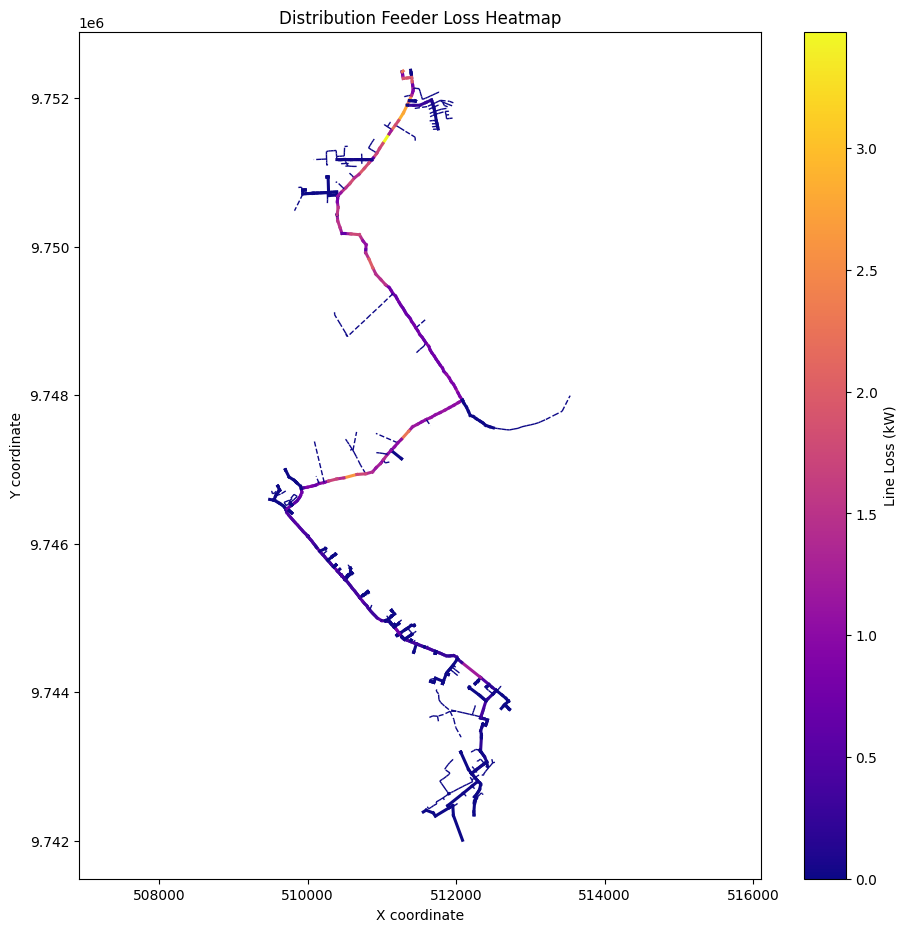

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import numpy as np
import pandas as pd

# -----------------------------
# 1. Extract line losses from OpenDSS
# -----------------------------

line_names = dss.Lines.AllNames()

loss_data = []

for line in line_names:

    dss.Lines.Name(line)

    losses = dss.CktElement.Losses()

    P_loss = losses[0] / 1000  # convert W → kW

    loss_data.append({
        "line": line,
        "P_loss_kW": P_loss
    })

loss_df = pd.DataFrame(loss_data)

print("Lines with losses:", len(loss_df))


# -----------------------------
# 2. Merge losses with geometry
# -----------------------------

# Normalize line names
loss_df["line"] = loss_df["line"].str.upper()
segments_df["line"] = segments_df["line"].str.upper()

# Merge losses with geometry
segments_loss_df = segments_df.merge(
    loss_df,
    on="line",
    how="left"
)

print("Segments with loss data:", segments_loss_df["P_loss_kW"].notna().sum())


# -----------------------------
# 3. Color scale for losses
# -----------------------------

# Determine scale automatically
loss_min = segments_loss_df["P_loss_kW"].min()
loss_max = segments_loss_df["P_loss_kW"].max()

norm = mcolors.Normalize(vmin=loss_min, vmax=loss_max)

cmap = mpl.colormaps["plasma"]  # good contrast for heatmaps


# -----------------------------
# 4. Plot loss heatmap
# -----------------------------

fig, ax = plt.subplots(figsize=(11,11))

for _, row in segments_loss_df.iterrows():

    x = [row["x1"], row["x2"]]
    y = [row["y1"], row["y2"]]

    color = cmap(norm(row["P_loss_kW"]))

    if row["phases"] == 3:
        lw = 2.2
        style = "-"
    else:
        lw = 1.0
        style = "--"

    ax.plot(x, y, color=color, linestyle=style, linewidth=lw)


# -----------------------------
# 5. Colorbar
# -----------------------------

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Line Loss (kW)")


# -----------------------------
# 6. Formatting
# -----------------------------

ax.set_title("Distribution Feeder Loss Heatmap")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

ax.axis("equal")

plt.show()

In [39]:
import pandas as pd

line_names = dss.Lines.AllNames()

length_data = []

for line in line_names:

    dss.Lines.Name(line)

    length = dss.Lines.Length()
    units = dss.Lines.Units()

    # Convert to km if necessary
    if units == 1:   # miles
        length = length * 1.60934
    elif units == 2: # kft
        length = length * 0.3048
    elif units == 3: # km
        pass
    elif units == 4: # meters
        length = length / 1000

    length_data.append({
        "line": line.upper(),
        "length_km": length
    })

length_df = pd.DataFrame(length_data)

print("Lines with length data:", len(length_df))
length_df.head()

Lines with length data: 1430


,line,length_km
0,N_23283_MTA,0.001000
1,N_7160_MTA,0.042521
2,N_115667_MTA,0.001277
3,N_42581_MTA,0.000355
4,N_7454_MTA,0.023201


LOSS DENSITY PLOT

Loss density (kW/km) is an engineering indicator to detect inefficient or overload conductors.

Loss density highlights true loss corridors such as: overloaded trunk sections, undersized conductors, strong downstream load concentrations. It is often used in reconductoring studies.

The worst-N lines are highlighted with red circle.

Segments with length: 1430
Loss density statistics (kW/km):
count    6.250000e+02
mean     4.551605e+00
std      7.263944e+00
min     -3.084378e-09
25%      2.861932e-03
50%      3.526588e-02
75%      9.050549e+00
max      3.311704e+01
Name: loss_density, dtype: float64
The worst loss-densed 20 line segments (kW/km):
             line  loss_density
598    N_7351_MTA     33.117037
934    N_7353_MTA     32.926836
665    N_7352_MTA     32.926697
191    N_7360_MTA     32.707632
1157  N_21852_MTA     32.689268
428   N_21853_MTA     32.594357
1124   N_7357_MTA     32.491721
97     N_7361_MTA     31.894640
222    N_7371_MTA     23.863331
888    N_7364_MTA     23.863087
152    N_7363_MTA     23.862917
1026   N_7362_MTA     23.862711
1006   N_7240_MTA     22.804747
983    N_7239_MTA     22.804619
21     N_7372_MTA     22.804426
978    N_7365_MTA     22.804253
115    N_7211_MTA     22.361913
1123   N_7212_MTA     22.246543
1165   N_7213_MTA     22.194459
569    N_7241_MTA     21.926487


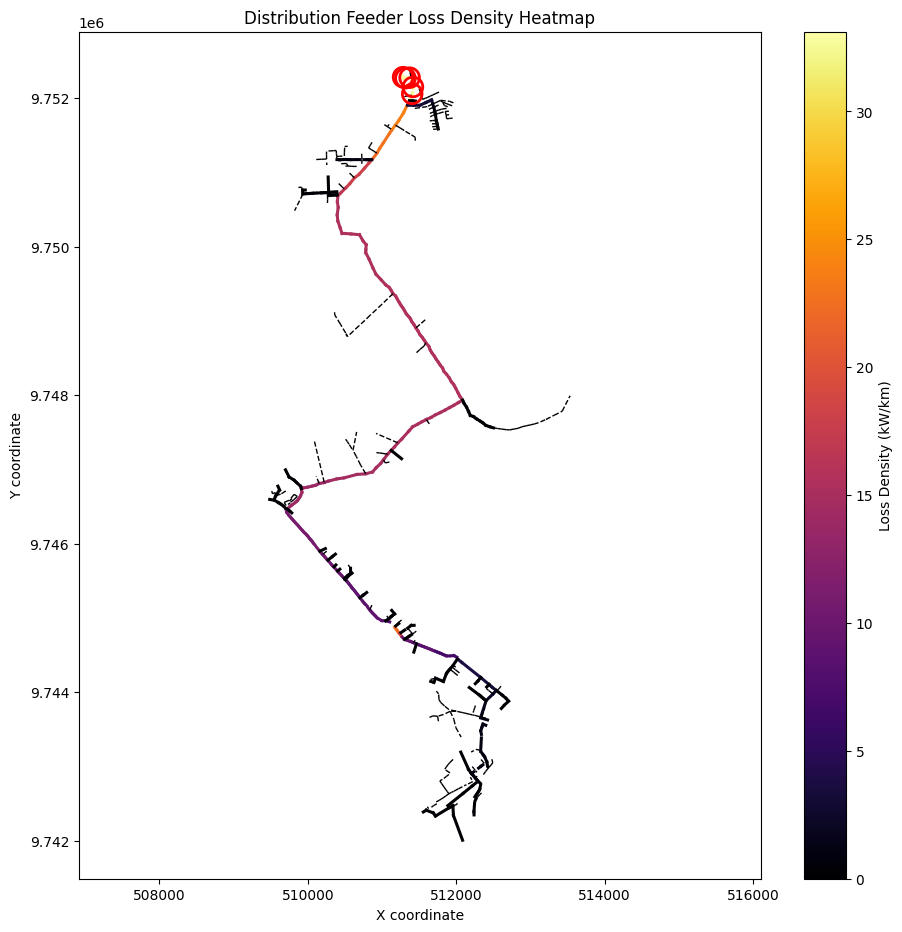

In [46]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import numpy as np

# -----------------------------
# Normalize names before merge
# -----------------------------

segments_df["line"] = segments_df["line"].str.upper()
loss_df["line"] = loss_df["line"].str.upper()
length_df["line"] = length_df["line"].str.upper()

# Remove existing length column if present
if "length_km" in segments_df.columns:
    segments_df = segments_df.drop(columns=["length_km"])

# Merge length into geometry
segments_df = segments_df.merge(
    length_df,
    on="line",
    how="left"
)

print("Segments with length:", segments_df["length_km"].notna().sum())


# Merge losses
segments_loss_df = segments_df.merge(
    loss_df,
    on="line",
    how="left"
)

# Filter very short segments
segments_loss_df = segments_loss_df[
    segments_loss_df["length_km"] > 0.03
]

# -----------------------------
# Compute loss density
# -----------------------------

segments_loss_df["loss_density"] = (
    segments_loss_df["P_loss_kW"] /
    segments_loss_df["length_km"].replace(0, np.nan)
)

# Replace infinities
segments_loss_df["loss_density"] = segments_loss_df["loss_density"].replace(
    [np.inf, -np.inf], np.nan
)

print("Loss density statistics (kW/km):")
print(segments_loss_df["loss_density"].describe())

print("The worst loss-densed 20 line segments (kW/km):")
segments_loss_df = segments_loss_df.sort_values("loss_density", ascending=False)
print(segments_loss_df[["line","loss_density"]].head(20))

# -----------------------------
# Color scale
# -----------------------------

ld_min = segments_loss_df["loss_density"].min()
ld_max = segments_loss_df["loss_density"].max()

norm = mcolors.Normalize(vmin=ld_min, vmax=ld_max)

cmap = mpl.colormaps["inferno"]   # good contrast

# -----------------------------
# Plot heatmap
# -----------------------------

fig, ax = plt.subplots(figsize=(11,11))

for _, row in segments_loss_df.iterrows():

    x = [row["x1"], row["x2"]]
    y = [row["y1"], row["y2"]]

    color = cmap(norm(row["loss_density"]))

    if row["phases"] == 3:
        lw = 2.2
        style = "-"
    else:
        lw = 1.0
        style = "--"

    ax.plot(x, y, color=color, linestyle=style, linewidth=lw)

# -----------------------------
# Highlight worst conductors
# -----------------------------

TOP_N = 5   # number of worst lines to highlight

worst_lines = segments_loss_df.nlargest(TOP_N, "loss_density")

for _, row in worst_lines.iterrows():

    xm = (row["x1"] + row["x2"]) / 2
    ym = (row["y1"] + row["y2"]) / 2

    ax.scatter(
        xm,
        ym,
        s=200,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        zorder=5
    )

# -----------------------------
# Colorbar
# -----------------------------

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Loss Density (kW/km)")

# -----------------------------
# Formatting
# -----------------------------

ax.set_title("Distribution Feeder Loss Density Heatmap")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

ax.axis("equal")

plt.show()